In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

from dataset import SceneTwoPairsDataset
from model import PairImageCylinderModel
from losses import supervised_loss

from debugger import bug_check


In [3]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

CUDA available: True
NVIDIA GeForce RTX 5050 Laptop GPU


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = PairImageCylinderModel(
    img_size=128,
    patch_size=16,
    in_chans=3,
    embed_dim=256,
    depth=4,
    num_heads=4,
    num_bins=32,
    dropout=0.1,
).to(device)

In [5]:
dataset = SceneTwoPairsDataset(
    root_dir="dataset",
    image_size=128,
    debugg=False,
)

loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
)

In [6]:
# bug_check(0)

In [7]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

model.train()
for epoch in range(100):
    total = 0.0
    total_vis = 0.0
    total_radius = 0-0
    total_depth = 0.0
    total_pose = 0.0
    total_t = 0.0
    total_r = 0.0

    for batch in loader:
        img_a, vision_a, img_b, pose_ab = batch

        img_a = img_a.to(device, non_blocking=True)
        img_b = img_b.to(device, non_blocking=True)
        vision_a = vision_a.to(device, non_blocking=True)
        pose_ab = pose_ab.to(device, non_blocking=True)

        pred_vision, pred_pose = model(img_a, img_b)

        loss_out = supervised_loss(
            pred_vision,
            vision_a,
            pred_pose,
            pose_ab,
            lambda_pose=1.0,
            lambda_vis_a=1.0,
            occ_thresh=0.5,
            lambda_occ=10.0,
            lambda_radius=10.0,
            lambda_depth=1.0,
            t_weight=1.0,
            r_weight=1.0,
        )

        loss = loss_out["total"]

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        total += loss.item()
        total_vis += loss_out["vision_a"].item()
        total_radius += loss_out["vision_a_radius"].item()
        total_pose += loss_out["pose"].item()
        total_depth += loss_out["vision_a_depth"].item()
        total_t += loss_out["translation"].item()
        total_r += loss_out["rotation"].item()

    n = len(loader)

    print(
        f"Epoch {epoch+1}: "
        f"total={total/n:.4f} | "
        f"vision={total_vis/n:.4f} | "
        f"radius={total_radius/n:.4f} | "
        f"depth={total_depth/n:.4f} | "
        f"pose={total_pose/n:.4f} | "
        f"t={total_t/n:.4f} | "
        f"r={total_r/n:.4f}"
    )

Epoch 1: total=14.8185 | vision=14.3828 | radius=0.1543 | depth=5.9584 | pose=0.4357 | t=0.2599 | r=0.1758
Epoch 2: total=14.3771 | vision=14.0664 | radius=0.1371 | depth=5.9198 | pose=0.3107 | t=0.2514 | r=0.0594
Epoch 3: total=14.0097 | vision=13.7008 | radius=0.1339 | depth=5.6574 | pose=0.3089 | t=0.2498 | r=0.0591
Epoch 4: total=14.1461 | vision=13.8373 | radius=0.1372 | depth=5.7690 | pose=0.3089 | t=0.2472 | r=0.0617
Epoch 5: total=13.9353 | vision=13.6315 | radius=0.1333 | depth=5.6086 | pose=0.3038 | t=0.2471 | r=0.0568
Epoch 6: total=14.0526 | vision=13.7504 | radius=0.1390 | depth=5.6824 | pose=0.3023 | t=0.2458 | r=0.0565
Epoch 7: total=13.7950 | vision=13.4612 | radius=0.1394 | depth=5.3790 | pose=0.3337 | t=0.2481 | r=0.0856
Epoch 8: total=13.3626 | vision=13.0570 | radius=0.1391 | depth=4.9952 | pose=0.3056 | t=0.2484 | r=0.0572
Epoch 9: total=13.1543 | vision=12.8489 | radius=0.1348 | depth=4.8420 | pose=0.3055 | t=0.2485 | r=0.0570
Epoch 10: total=12.7318 | vision=12.4

In [8]:
# Inference + utskrift + plottar på samma dataset som träningen
from utils import pose_to_text, show_image_pair

# Samma dataset som i träningen, men utan shuffle för stabil visualisering
infer_loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0,
)

model.eval()

batch = next(iter(infer_loader))
img_a, vision_a, img_b, pose_ab = batch

img_a = img_a.to(device)
vision_a = vision_a.to(device)
img_b = img_b.to(device)
pose_ab = pose_ab.to(device)

with torch.no_grad():
    pred_vision, pred_pose = model(img_a, img_b)

# Skriv ut resultat för några samples
n_show = min(4, img_a.shape[0])
for i in range(n_show):
    print(f"Sample {i}")
    print("  GT   pose:", pose_to_text(pose_ab[i].detach().cpu()))
    print("  Pred pose:", pose_to_text(pred_pose[i].detach().cpu()))

    pose_err = torch.abs(pred_pose[i] - pose_ab[i]).detach().cpu()
    print(f"  |err|     : tx={pose_err[0]:.3f}, ty={pose_err[1]:.3f}, sin={pose_err[2]:.3f}, cos={pose_err[3]:.3f}")
    print()

Sample 0
  GT   pose: tx=-0.151, ty=-0.989, yaw=-6.8°
  Pred pose: tx=-0.500, ty=-0.756, yaw=-5.4°
  |err|     : tx=0.350, ty=0.233, sin=0.024, cos=0.003

Sample 1
  GT   pose: tx=-0.910, ty=-0.415, yaw=-7.9°
  Pred pose: tx=-0.863, ty=-0.475, yaw=-4.5°
  |err|     : tx=0.046, ty=0.059, sin=0.060, cos=0.007

Sample 2
  GT   pose: tx=0.416, ty=0.909, yaw=-12.7°
  Pred pose: tx=0.130, ty=0.956, yaw=-10.7°
  |err|     : tx=0.286, ty=0.047, sin=0.036, cos=0.007

Sample 3
  GT   pose: tx=-0.520, ty=0.854, yaw=4.8°
  Pred pose: tx=-0.763, ty=0.592, yaw=0.8°
  |err|     : tx=0.243, ty=0.263, sin=0.070, cos=0.003



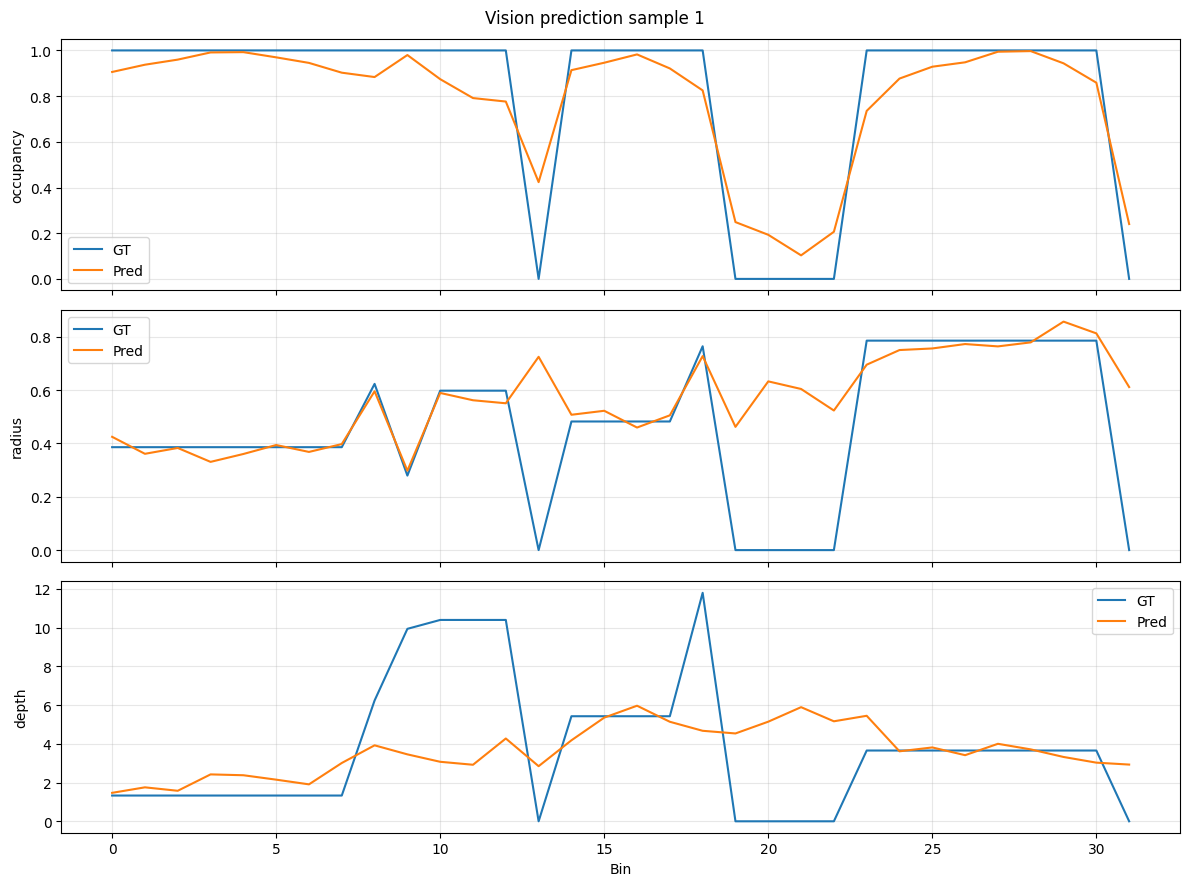

In [14]:
# Plotta vision-output för första samplet
sample_idx = 1
bins = np.arange(pred_vision.shape[1])

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

names = ["occupancy", "radius", "depth"]
for j, ax in enumerate(axes):
    gt = vision_a[sample_idx, :, j].detach().cpu().numpy()
    pr = pred_vision[sample_idx, :, j].detach().cpu().numpy()

    ax.plot(bins, gt, label="GT")
    ax.plot(bins, pr, label="Pred")
    ax.set_ylabel(names[j])
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Bin")
fig.suptitle(f"Vision prediction sample {sample_idx}")
plt.tight_layout()
plt.show()

# Plotta bildpar
if False:
    for i in range(n_show):
        show_image_pair(
            img_a[i].detach().cpu(),
            img_b[i].detach().cpu(),
            title=f"Sample {i} | GT pose: {pose_to_text(pose_ab[i].detach().cpu())}"
        )

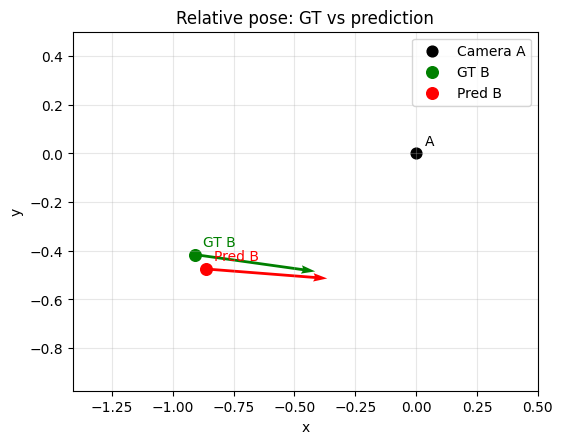

pred_vision shape: torch.Size([4, 32, 3])
pred_pose shape: torch.Size([4, 4])
GT pose: tensor([-0.9096, -0.4155, -0.1382,  0.9904])
Pred pose: tensor([-0.8635, -0.4747, -0.0779,  0.9970])


In [15]:
import matplotlib.pyplot as plt
import torch
import numpy as np

from utils import plot_relative_pose


# Visa första paret i batchen
if False:
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    axes[0].imshow(img_a[sample_idx].cpu().permute(1, 2, 0))
    axes[0].set_title("Image A")
    axes[0].axis("off")

    axes[1].imshow(img_b[sample_idx].cpu().permute(1, 2, 0))
    axes[1].set_title("Image B")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

# Visa relative pose
plot_relative_pose(pose_ab[sample_idx], pred_pose[sample_idx])

print("pred_vision shape:", pred_vision.shape)
print("pred_pose shape:", pred_pose.shape)
print("GT pose:", pose_ab[sample_idx].detach().cpu())
print("Pred pose:", pred_pose[sample_idx].detach().cpu())